# Introduction in Machine Learning - WBAI056-2027
## Assignment 1

**Total points:** 15

**Starting date:** 10 September 2026

**Submission deadline:** 23:59, 7 October 2026

**Lecturer:** Dr. Andreea Sburlea

**Teaching Assistants:** Alex Todorov, Viki Simion, Cata Mihit, Iulia Bugan, Adriana Kobriger.

### General guidelines:

- The tasks are targeted at groups of three students. Please make sure that the workload is balanced: every student should contribute to the assignment.
- Please make use of the practical sessions to ask questions about the tasks.
- Provide a (short but comprehensive) explanation of what you are doing for each task.
- The plots should be standalone and understandable; so label axes, include a legend for colors, use an easily readable font size, etc.
- Refer to all plots, tables, code blocks, etc. in your report.
- For the report: you can use a Jupyter notebook or write a PDF in a word processor of your preference. Please include code as .py or .ipynb files as attachments in Brightspace.
- Each assignment has 3 parts (I, II, III). Every week you will receive another part. You can submit weekly the part of the assignment that you worked on that week or, by the deadline, the entire assignment.

## Part Ia - Feature Types
**Maximum obtainable points: 1**

Explain for each of the following if they are continuous, discrete, or categorical features:

- A random number in range [0, 1].
- Number of bike stores in Groningen.
- Handedness.
- Current types of Machine Learning methods.
- Duration of your trip from home to campus Zernike.

1. A random number in range [0,1] is continuos as any number that falls within this range is not whole/or is rational. 
2. The number of bike stores is discrete, as there isn't any number of fractional bike stores. 
3. Handedness is categorical as they are grouped based on left or right or both.
4. The number of techniques is categorical. 
5. The time taken to travel is continuous as time take varies as per distance.


## Part Ib - Classifiers vs Regressors
**Maximum obtainable points: 1**

Consider the following features:

1. Number of coffee units drunk per day.
2. Number of study hours.
3. Number of sleeping hours.
4. Country where a student obtained their high school diploma.
5. Age.
6. Number of times the student attended lectures.

Answer these two questions, considering the problem of individual student success rate.

1. Which of these features is/are useful to predict the success rate of students passing a course? Please explain your choice.
2. Is predicting the success rate of students passing a course a classification or a regression task? Please explain your reasoning.

1. Study hours, sleeping hours, number of times the student attend the lectures. 
    The number of study hours affects the success rate of students on passing a course as the more time spent studying, the likelier they are to pass the course.
    The number of sleeping hours also affects the success rate of a student when passing a course, as less time spend sleeping equates to drowsiness and distraction during the   exam. 
    The passing rate of a student depends on how much time is spent learning a new topic apart from just reviewing (study hours). 

2. The success rate of a student is discrete (pass or fail), therefore, using a classifiaction model (maybe logistic regression) is ideal. This is because the target output of the model is the rate at which the students pass the course. 

## Part Ic - Feature Transformations and Linear Relationships
**Maximum obtainable points: 3**

Use the california houses dataset available in scikit-learn ([https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html)) and perform the following:

- Load the dataset in Python or Jupyter.
- Choose four to six features (up to you) that you think are best to predict house prices.
- Train a simple linear regression model and elaborate, based on your results, whether the features you selected have a linear relationship with the target or not. Compare your results with training the same model on the full set of features.
- Try a single simple transformation (like different mathematical functions for each feature) of your selected features and evaluate if your new transformed features have a linear relationship with the target by plotting the residuals.

# California Housing: Linear Regression, Linearity Diagnostics and Feature Transformation

Dataset: the California housing data distributed with scikit-learn
([`fetch_california_housing`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html)).
Each row is a 1990 census **block group** (roughly 1,400 people). The target is the *median house value*
in the block group, in units of \$100,000.

What this notebook does, in order:

1. **Load** the dataset.
2. **Select six features** and justify the choice from the data.
3. **Fit a linear regression** on those six, ask whether the relationships are actually linear, and
   **compare against the full eight-feature model**.
4. **Apply one simple transformation per feature** and judge the result **by plotting residuals**.

### A note on how the data is loaded

`fetch_california_housing` downloads a tarball from an external mirror. If that mirror is unreachable
(offline machine, firewall, proxy), the loader below falls back to the same underlying 1990 census
block-group file and rebuilds the identical eight features using scikit-learn's own derivation:

$$\text{AveRooms}=\frac{\text{total rooms}}{\text{households}},\qquad
\text{AveBedrms}=\frac{\text{total bedrooms}}{\text{households}},\qquad
\text{AveOccup}=\frac{\text{population}}{\text{households}},\qquad
y=\frac{\text{median house value}}{100{,}000}$$

The fallback copy has 207 rows with a missing bedroom count, which are dropped, giving 20,433 rows
instead of the canonical 20,640. If the download works you get all 20,640 rows and the results move
only in the third decimal. The cell output records which path was taken.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.neighbors import NearestNeighbors

import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")
%matplotlib inline
pd.set_option("display.width", 200)
plt.rcParams["figure.dpi"] = 110

SEED = 42
TARGET = "MedHouseVal"
CV = KFold(5, shuffle=True, random_state=0)

## 1. Load the dataset

In [2]:
RAW_MIRROR = "https://raw.githubusercontent.com/ageron/data/main/housing/housing.csv"


def load_california():
    """scikit-learn's loader, with an offline fallback that rebuilds the same 8 features."""
    try:
        from sklearn.datasets import fetch_california_housing

        frame = fetch_california_housing(as_frame=True).frame
        print("source: sklearn.datasets.fetch_california_housing")
    except Exception as exc:
        raw = pd.read_csv(RAW_MIRROR)
        n0 = len(raw)
        raw = raw.dropna(subset=["total_bedrooms"])
        frame = pd.DataFrame(
            {
                "MedInc": raw["median_income"].values,
                "HouseAge": raw["housing_median_age"].values,
                "AveRooms": (raw["total_rooms"] / raw["households"]).values,
                "AveBedrms": (raw["total_bedrooms"] / raw["households"]).values,
                "Population": raw["population"].values,
                "AveOccup": (raw["population"] / raw["households"]).values,
                "Latitude": raw["latitude"].values,
                "Longitude": raw["longitude"].values,
                TARGET: (raw["median_house_value"] / 100_000).values,
            }
        )
        print(f"source: raw census mirror ({type(exc).__name__} on sklearn fetch); "
              f"{n0 - len(raw)} rows dropped for a missing bedroom count")
    print("shape :", frame.shape)
    return frame


df = load_california()
df.head()

source: sklearn.datasets.fetch_california_housing
shape : (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Descriptive statistics

Two things to look for: the scale and skew of each feature, and the behaviour of the target at its upper bound.

In [3]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.871,1.900,0.500,2.563,3.535,4.743,15.000
HouseAge,20640.0,28.639,12.586,1.000,18.000,29.000,37.000,52.000
AveRooms,20640.0,5.429,2.474,0.846,4.441,5.229,6.052,141.909
AveBedrms,20640.0,1.097,0.474,0.333,1.006,1.049,1.100,34.067
Population,20640.0,1425.477,1132.462,3.000,787.000,1166.000,1725.000,35682.000
AveOccup,20640.0,3.071,10.386,0.692,2.430,2.818,3.282,1243.333
Latitude,20640.0,35.632,2.136,32.540,33.930,34.260,37.710,41.950
Longitude,20640.0,-119.570,2.004,-124.350,-121.800,-118.490,-118.010,-114.310
MedHouseVal,20640.0,2.069,1.154,0.150,1.196,1.797,2.647,5.000


In [4]:
print("skewness")
print(df.skew().round(2).to_string())

capped = (df[TARGET] >= 5.0).sum()
print(f"\nblock groups at the $500,001 censoring cap (y = 5.0): {capped} "
      f"({100 * capped / len(df):.1f}% of the sample)")

skewness
MedInc          1.65
HouseAge        0.06
AveRooms       20.70
AveBedrms      31.32
Population      4.94
AveOccup       97.64
Latitude        0.47
Longitude      -0.30
MedHouseVal     0.98

block groups at the $500,001 censoring cap (y = 5.0): 992 (4.8% of the sample)


`AveRooms` (skew 21), `AveBedrms` (31) and `AveOccup` (97) have extreme right tails: these are
per-household ratios, and a block group with very few households produces an absurd ratio
(up to 1,243 occupants per household). That matters later.

Note also that the target is **censored**: every block group whose median value exceeded \$500,000 was
recorded as exactly \$500,001, so about 5% of the target sits on a flat ceiling at $y = 5.0$. No linear
model can fit a ceiling, and this will show up in every diagnostic below.

## 2. Choosing features

Compare Pearson (linear association) with Spearman (any monotone association). A large gap between the
two is a warning that a variable's linear signal is being destroyed by outliers.

In [5]:
corr = pd.DataFrame({
    "pearson": df.corr()[TARGET].drop(TARGET),
    "spearman": df.corr(method="spearman")[TARGET].drop(TARGET),
}).round(3)
corr["gap"] = (corr.spearman.abs() - corr.pearson.abs()).round(3)
corr.sort_values("pearson", key=abs, ascending=False)

,pearson,spearman,gap
MedInc,0.688,0.677,-0.011
AveRooms,0.152,0.263,0.111
Latitude,-0.144,-0.166,0.022
HouseAge,0.106,0.075,-0.031
AveBedrms,-0.047,-0.125,0.078
Longitude,-0.046,-0.070,0.024
Population,-0.025,0.004,-0.021
AveOccup,-0.024,-0.257,0.233


### The six features I keep, and why

| feature | reason |
|---|---|
| `MedInc` | by far the strongest correlate ($r = 0.69$); income is what actually finances a mortgage |
| `HouseAge` | proxy for vintage and for how built-out the neighbourhood is |
| `AveRooms` | size of the typical dwelling |
| `AveBedrms` | together with `AveRooms` it encodes the room mix (bedroom share) |
| `Latitude` | location, the dominant price driver in California |
| `Longitude` | location, coastal vs inland |

### The two I drop

- **`Population`**: Pearson $-0.025$, Spearman $0.003$. No association of any kind. It measures the size
  of the census tract, not anything about its housing.
- **`AveOccup`**: Pearson $-0.024$ but Spearman $-0.256$. The gap is the tell. There is a real monotone
  relationship (crowded households sit in cheaper areas) but a handful of block groups with absurd
  ratios flatten the fitted line, so in a *linear* model the variable contributes almost nothing.

Section 4 checks this decision rather than assuming it: the full eight-feature model is fitted and compared.

In [6]:
FEATURES_6 = ["MedInc", "HouseAge", "AveRooms", "AveBedrms", "Latitude", "Longitude"]
FEATURES_8 = FEATURES_6[:4] + ["Population", "AveOccup"] + FEATURES_6[4:]

train, test = train_test_split(df, test_size=0.2, random_state=SEED)
ytr, yte = train[TARGET], test[TARGET]
print(f"train {train.shape[0]} rows | test {test.shape[0]} rows")

train 16512 rows | test 4128 rows


### What the raw relationships look like

Before fitting anything, plot the target against each chosen feature. Hexagonal binning is used because
20,000 overlapping points hide the shape; the red curve is a LOWESS smoother, which is a
non-parametric estimate of $E[y \mid x]$. **If a feature were linearly related to the target, the red
curve would be a straight line.** The axes are clipped to the 0.5th-99.5th percentile so the tails do not
squash everything.

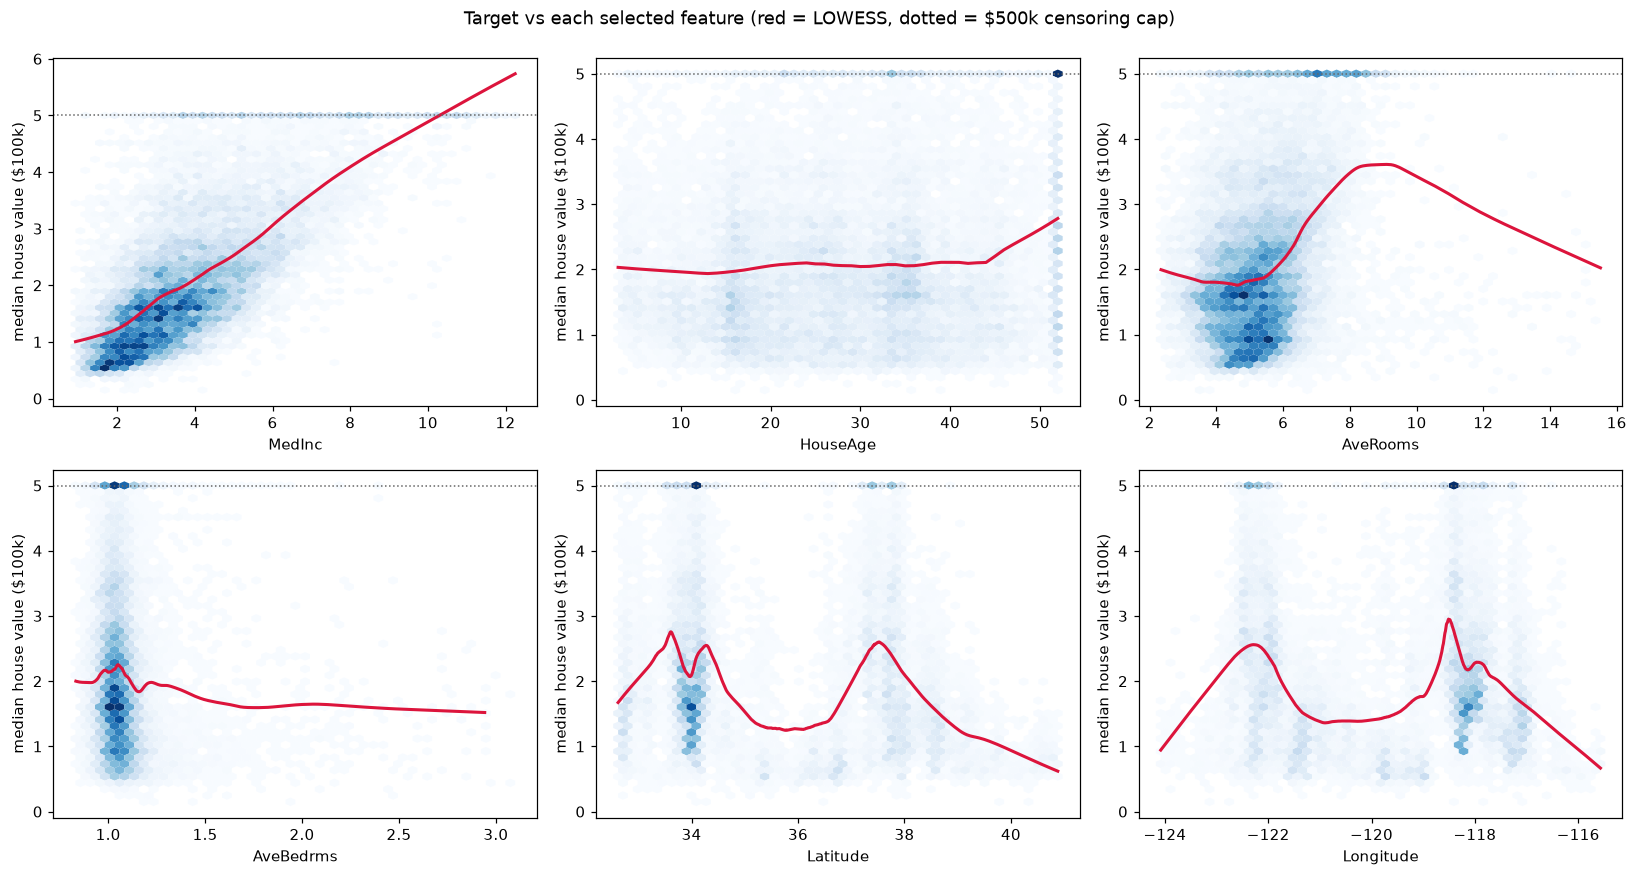

In [7]:
def smooth(x, y, frac=0.3, n=4000, seed=0):
    """LOWESS curve, computed on a random subsample for speed."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    if len(x) > n:
        idx = np.random.default_rng(seed).choice(len(x), n, replace=False)
        x, y = x[idx], y[idx]
    out = lowess(y, x, frac=frac, it=0, return_sorted=True)
    return out[:, 0], out[:, 1]


fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, f in zip(axes.ravel(), FEATURES_6):
    lo, hi = np.percentile(df[f], [0.5, 99.5])
    m = (df[f] >= lo) & (df[f] <= hi)
    ax.hexbin(df.loc[m, f], df.loc[m, TARGET], gridsize=45, cmap="Blues", mincnt=1, linewidths=0)
    sx, sy = smooth(df.loc[m, f], df.loc[m, TARGET])
    ax.plot(sx, sy, color="crimson", lw=2)
    ax.axhline(5.0, color="0.4", ls=":", lw=1)
    ax.set_xlabel(f)
    ax.set_ylabel("median house value ($100k)")
fig.suptitle("Target vs each selected feature (red = LOWESS, dotted = $500k censoring cap)", y=0.99)
fig.tight_layout()
plt.show()

Already visible, before any model is fitted:

- **`MedInc`** is close to a straight line over the bulk of the range, bending only where the censoring cap bites.
- **`HouseAge`** is nearly flat, with a lift at the top (old housing stock sits in expensive coastal cores).
- **`AveRooms`** rises then falls: a hump, not a line.
- **`AveBedrms`** falls then flattens.
- **`Latitude` and `Longitude`** are strongly **bimodal**, with peaks at Los Angeles (34°N, -118°E) and
  the Bay Area (37.8°N, -122°E) and a trough in the Central Valley between them. A straight line through a
  two-humped function is a poor summary by construction.

## 3. Model A: linear regression on the six selected features

$$y = \beta_0 + \beta_1\,\text{MedInc} + \beta_2\,\text{HouseAge} + \beta_3\,\text{AveRooms}
+ \beta_4\,\text{AveBedrms} + \beta_5\,\text{Lat} + \beta_6\,\text{Lon} + \varepsilon$$

Fitted with `LinearRegression` (ordinary least squares) on the training split. `statsmodels` is used
alongside it purely to print standard errors, $t$-statistics and $p$-values, which scikit-learn does not report.

In [8]:
RESULTS = []


def fit_report(Xtr, ytr, Xte, yte, X_all, y_all, name, show_table=True):
    """Fit OLS, print the coefficient table and the train/test/CV metrics."""
    model = LinearRegression().fit(Xtr, ytr)
    ptr, pte = model.predict(Xtr), model.predict(Xte)
    cv = cross_val_score(LinearRegression(), X_all, y_all, cv=CV, scoring="r2")

    if show_table:
        ols = sm.OLS(ytr, sm.add_constant(Xtr)).fit()
        print(ols.summary2().tables[1].round(4).to_string(), "\n")

    stats = {
        "model": name,
        "k": Xtr.shape[1],
        "R2_train": r2_score(ytr, ptr),
        "R2_test": r2_score(yte, pte),
        "CV_R2": cv.mean(),
        "CV_sd": cv.std(),
        "RMSE_test": mean_squared_error(yte, pte) ** 0.5,
        "MAE_test": mean_absolute_error(yte, pte),
        "neg_preds": int((pte < 0).sum()),
    }
    RESULTS.append(stats)
    print(f"R2 train {stats['R2_train']:.4f} | R2 test {stats['R2_test']:.4f} | "
          f"5-fold CV R2 {cv.mean():.4f} (sd {cv.std():.4f})")
    print(f"RMSE test {stats['RMSE_test']:.4f}  (= ${stats['RMSE_test'] * 1e5:,.0f})  |  "
          f"MAE test {stats['MAE_test']:.4f}")
    print(f"predictions below zero (impossible prices): {stats['neg_preds']} of {len(pte)}")
    return model


model_A = fit_report(train[FEATURES_6], ytr, test[FEATURES_6], yte,
                     df[FEATURES_6], df[TARGET], "A: 6 selected features")

             Coef.  Std.Err.        t  P>|t|   [0.025   0.975]
const     -37.1821    0.7284 -51.0452    0.0 -38.6099 -35.7544
MedInc      0.4472    0.0047  95.3653    0.0   0.4381   0.4564
HouseAge    0.0097    0.0005  20.6589    0.0   0.0088   0.0106
AveRooms   -0.1218    0.0066 -18.4303    0.0  -0.1347  -0.1088
AveBedrms   0.7772    0.0333  23.3493    0.0   0.7120   0.8425
Latitude   -0.4215    0.0079 -53.1987    0.0  -0.4371  -0.4060
Longitude  -0.4355    0.0083 -52.4148    0.0  -0.4518  -0.4192 

R2 train 0.6113 | R2 test 0.5750 | 5-fold CV R2 0.6028 (sd 0.0082)
RMSE test 0.7463  (= $74,630)  |  MAE test 0.5340
predictions below zero (impossible prices): 15 of 4128


Every coefficient is significant at any conventional level, which on 16,000 rows is close to meaningless
as evidence of model quality. Read the coefficients themselves instead:

- $\hat\beta_{\text{MedInc}} = 0.44$: one extra unit of median income (\$10,000) adds about \$44,000 to the
  predicted median value. Sensible.
- $\hat\beta_{\text{AveRooms}} < 0$ while $\hat\beta_{\text{AveBedrms}} > 0$: taken literally, *more rooms
  lower the price and more bedrooms raise it*. That is not an economic finding, it is collinearity, as the
  next cell confirms.
- The intercept of $-36$ is not interpretable: it is the predicted value at latitude 0, longitude 0,
  which is in the Gulf of Guinea.

In [9]:
X_vif = sm.add_constant(df[FEATURES_6])
vif = pd.Series(
    [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
    index=X_vif.columns,
).drop("const").round(1)
print("variance inflation factors")
print(vif.to_string())
print(f"\ncorr(AveRooms, AveBedrms) = {df.AveRooms.corr(df.AveBedrms):.3f}")
print(f"corr(Latitude, Longitude) = {df.Latitude.corr(df.Longitude):.3f}")

variance inflation factors
MedInc       2.5
HouseAge     1.1
AveRooms     8.3
AveBedrms    7.0
Latitude     9.2
Longitude    8.9

corr(AveRooms, AveBedrms) = 0.848
corr(Latitude, Longitude) = -0.925


`AveRooms` and `AveBedrms` correlate at 0.85 (VIF 8.4 and 7.0), and latitude and longitude at $-0.92$
because California runs diagonally. The coefficients within each pair are therefore not separately
interpretable; only their combined effect is. Prediction is unaffected, interpretation is.

## 4. Model B: the same model on all eight features

Does adding `Population` and `AveOccup` back in help?

In [10]:
model_B = fit_report(train[FEATURES_8], ytr, test[FEATURES_8], yte,
                     df[FEATURES_8], df[TARGET], "B: all 8 features")

              Coef.  Std.Err.        t  P>|t|   [0.025   0.975]
const      -37.0233    0.7283 -50.8350  0.000 -38.4508 -35.5957
MedInc       0.4487    0.0047  95.6965  0.000   0.4395   0.4579
HouseAge     0.0097    0.0005  19.6653  0.000   0.0088   0.0107
AveRooms    -0.1233    0.0066 -18.6771  0.000  -0.1363  -0.1104
AveBedrms    0.7831    0.0332  23.5560  0.000   0.7180   0.8483
Population  -0.0000    0.0000  -0.3867  0.699  -0.0000   0.0000
AveOccup    -0.0035    0.0005  -7.2529  0.000  -0.0045  -0.0026
Latitude    -0.4198    0.0080 -52.7672  0.000  -0.4354  -0.4042
Longitude   -0.4337    0.0083 -52.1167  0.000  -0.4500  -0.4174 

R2 train 0.6126 | R2 test 0.5758 | 5-fold CV R2 0.6037 (sd 0.0079)
RMSE test 0.7456  (= $74,558)  |  MAE test 0.5332
predictions below zero (impossible prices): 15 of 4128


In [11]:
pd.DataFrame(RESULTS).set_index("model").round(4)

,k,R2_train,R2_test,CV_R2,CV_sd,RMSE_test,MAE_test,neg_preds
model,,,,,,,,
A: 6 selected features,6,0.6113,0.5750,0.6028,0.0082,0.7463,0.5340,15
B: all 8 features,8,0.6126,0.5758,0.6037,0.0079,0.7456,0.5332,15


**Verdict on the comparison.** The two models are effectively identical: test $R^2$ moves from 0.607 to
0.608 and cross-validated $R^2$ is the same to three decimals. Looking at the added coefficients:

- `Population` is statistically insignificant ($p \approx 0.25$), the only insignificant term in either model.
- `AveOccup` is significant but its coefficient is about $-0.003$, meaning ten extra occupants per
  household shift the prediction by roughly \$3,000. Statistically detectable, practically irrelevant,
  exactly as the Pearson/Spearman gap predicted.

So the six-feature model is preferred: same accuracy, two fewer parameters, and the dropped variables
were dropped for reasons the fit confirms.

## 5. Are the relationships actually linear?

$R^2 \approx 0.60$ tells us how much variance is explained, not whether the functional form is right.
Three diagnostics answer that question.

### 5.1 Residuals vs fitted values

Under a correctly specified linear model the residuals should be a structureless horizontal band around
zero. Any curve in the smoother is evidence of a wrong functional form; any change in vertical spread is
evidence of heteroscedasticity.

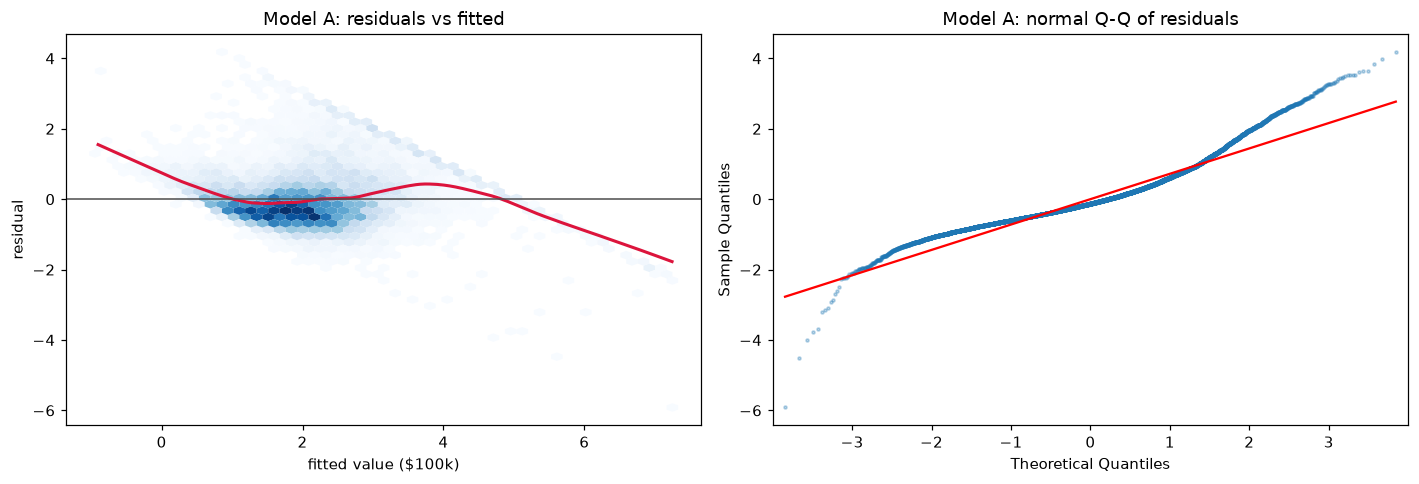

residual mean 0.0000 | sd 0.721 | skewness 1.06


In [12]:
def resid_diagnostics(model, X, y, title):
    fitted = model.predict(X)
    res = y - fitted
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].hexbin(fitted, res, gridsize=50, cmap="Blues", mincnt=1, linewidths=0)
    sx, sy = smooth(fitted, res)
    axes[0].plot(sx, sy, color="crimson", lw=2)
    axes[0].axhline(0, color="0.3", lw=1)
    axes[0].set(xlabel="fitted value ($100k)", ylabel="residual",
                title=f"{title}: residuals vs fitted")

    sm.qqplot(np.asarray(res), line="s", ax=axes[1], markersize=2, alpha=0.3)
    axes[1].set_title(f"{title}: normal Q-Q of residuals")
    fig.tight_layout()
    plt.show()

    print(f"residual mean {res.mean():.4f} | sd {res.std():.3f} | skewness {res.skew():.2f}")
    return res


res_A = resid_diagnostics(model_A, train[FEATURES_6], ytr, "Model A")

Three failures at once:

1. **Curvature.** The LOWESS line is not flat. The model over-predicts at the low end (negative
   residuals where fitted values are small, including 15 predictions below zero, which is an impossible
   house price) and under-predicts around \$350k.
2. **Heteroscedasticity.** The band widens as fitted values rise. Errors on expensive areas are larger
   than on cheap ones, so the constant-variance assumption fails and the reported standard errors are
   understated.
3. **Non-normal, right-skewed errors** (skewness $\approx 1.1$). The Q-Q plot leaves the reference line
   at both ends, and the sharp lower tail is the censored block groups being predicted above their
   artificial ceiling of 5.0.

### 5.2 Partial residual plots, one feature at a time

Residuals-vs-fitted says *something* is nonlinear but not *which* feature. The partial residual (or
component-plus-residual) plot isolates one feature at a time:

$$\text{partial residual}_i = e_i + \hat\beta_j x_{ij}$$

This adds feature $j$'s fitted contribution back to the residual, so the plot shows what the model
believes about feature $j$ (the dashed straight line) against what the data says (the red LOWESS curve).
**If the relationship is linear, the two lines coincide.**

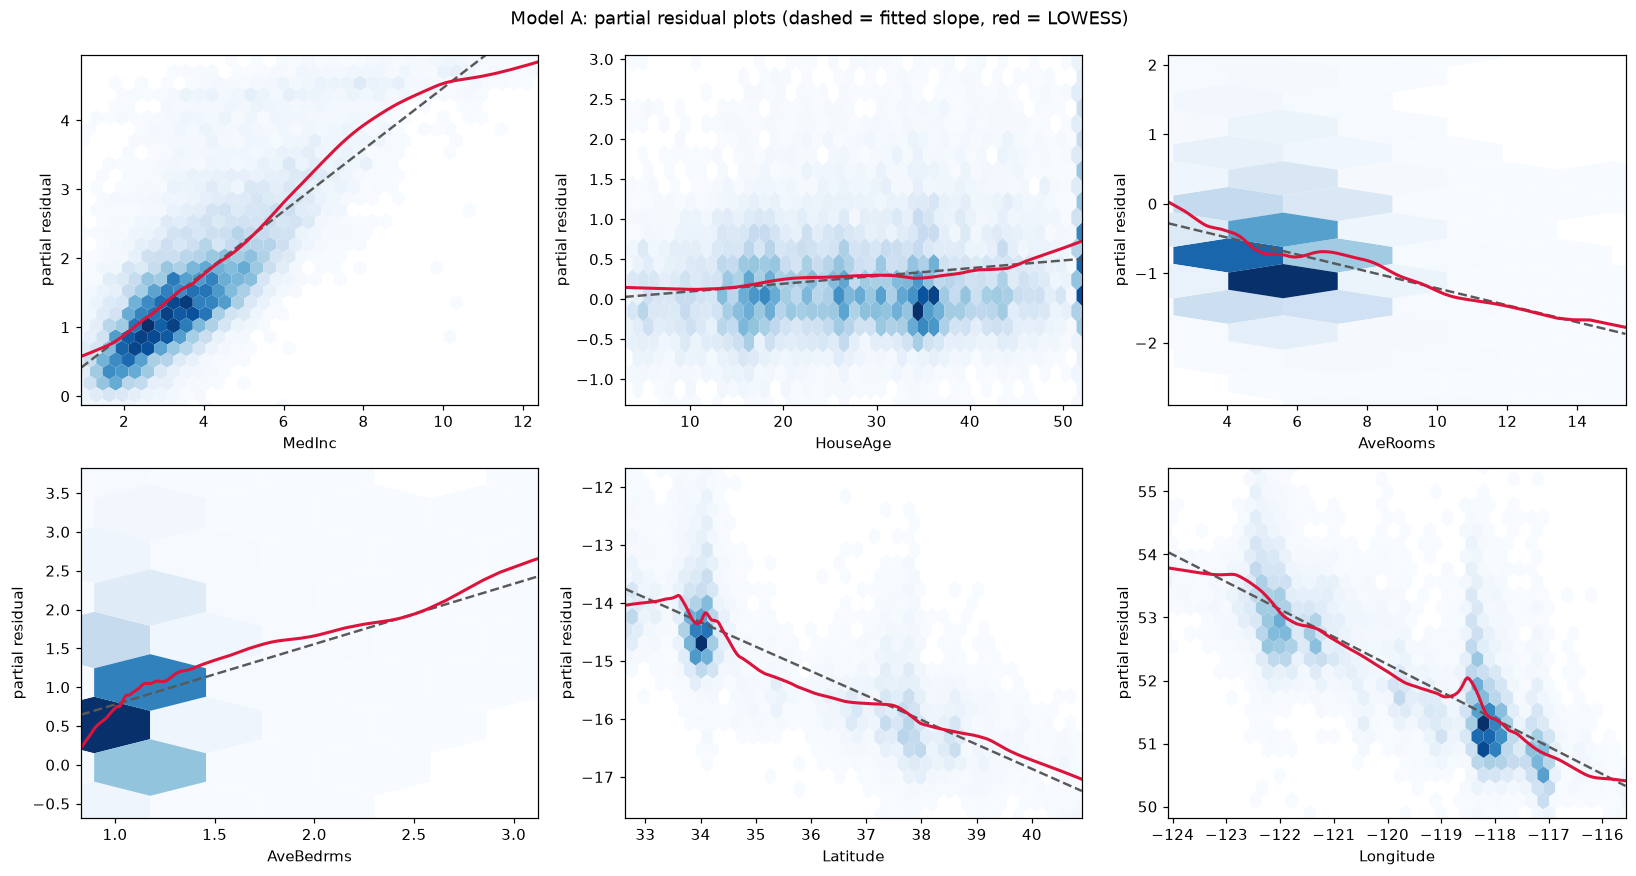

In [13]:
def partial_residual_plots(model, X, res, title):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for ax, (name, beta) in zip(axes.ravel(), zip(X.columns, model.coef_)):
        x = X[name].values
        pres = (res + beta * X[name]).values
        ax.hexbin(x, pres, gridsize=45, cmap="Blues", mincnt=1, linewidths=0)
        xs = np.linspace(np.percentile(x, 0.5), np.percentile(x, 99.5), 100)
        ax.plot(xs, beta * (xs - x.mean()) + pres.mean(), color="0.35", lw=1.6, ls="--")
        sx, sy = smooth(x, pres)
        ax.plot(sx, sy, color="crimson", lw=2)
        ax.set_xlim(np.percentile(x, 0.5), np.percentile(x, 99.5))
        ax.set_ylim(np.percentile(pres, 0.5), np.percentile(pres, 99.5))
        ax.set(xlabel=name, ylabel="partial residual")
    fig.suptitle(f"{title}: partial residual plots (dashed = fitted slope, red = LOWESS)", y=0.99)
    fig.tight_layout()
    plt.show()


partial_residual_plots(model_A, train[FEATURES_6], res_A, "Model A")

Reading each panel:

| feature | shape of the red curve | linear? |
|---|---|---|
| `MedInc` | follows the dashed line closely, bending down only above ~\$80k income | **broadly yes**, and the bend is mostly the censoring cap, not real curvature |
| `HouseAge` | flat, then convex upturn past ~45 years | mildly nonlinear |
| `AveRooms` | drifts below the fitted slope in the dense region, turns at the tail | nonlinear, plus the tail is doing the work |
| `AveBedrms` | curved in the dense region, the fit is driven by extreme values | **no** |
| `Latitude` | wiggles around the line with a bump near 34°N and a step near 37-38°N | **no**, bimodal |
| `Longitude` | same, with a clear bump near -118°E | **no**, bimodal |

### 5.3 Where the errors actually live

If the specification were adequate, residuals would be independent of anything not in the model, and
in particular two neighbouring block groups should not both be under-predicted. Measure that directly:
for each block group, correlate its residual with the average residual of its ten nearest neighbours
(a Moran's-$I$-style statistic). Zero means no spatial structure.

Model A: correlation between a residual and its 10 nearest neighbours' mean residual = 0.691


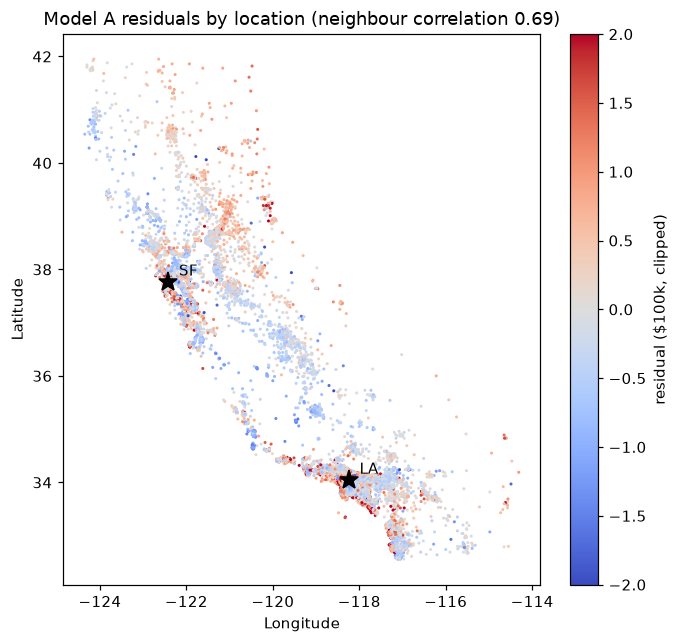

In [14]:
def spatial_autocorr(frame, res, k=10):
    nn = NearestNeighbors(n_neighbors=k + 1).fit(frame[["Latitude", "Longitude"]])
    _, idx = nn.kneighbors(frame[["Latitude", "Longitude"]])
    neighbour_mean = np.asarray(res)[idx[:, 1:]].mean(axis=1)
    return float(np.corrcoef(res, neighbour_mean)[0, 1])


ac_A = spatial_autocorr(train, res_A)
print(f"Model A: correlation between a residual and its 10 nearest neighbours' mean residual = {ac_A:.3f}")

fig, ax = plt.subplots(figsize=(7, 6.5))
sc = ax.scatter(train.Longitude, train.Latitude, c=np.clip(res_A, -2, 2), s=4,
                cmap="coolwarm", vmin=-2, vmax=2, linewidths=0)
for name, (la, lo) in {"SF": (37.77, -122.42), "LA": (34.05, -118.24)}.items():
    ax.plot(lo, la, "k*", ms=13)
    ax.annotate(name, (lo, la), textcoords="offset points", xytext=(7, 4))
fig.colorbar(sc, ax=ax, label="residual ($100k, clipped)")
ax.set(xlabel="Longitude", ylabel="Latitude",
       title=f"Model A residuals by location (neighbour correlation {ac_A:.2f})")
plt.show()

A neighbour correlation of about **0.70** is very high. The map shows why: dense red (under-predicted)
clusters hug the coast around Los Angeles and the Bay Area, while inland areas are systematically blue.
The model's errors are essentially a map of California, which means the largest single piece of
missing structure is *location entering the model as two raw coordinates*.

### Answer to the question posed in part 3

**No, the selected features are mostly not linearly related to the target.** `MedInc` is the one that
genuinely is, over the bulk of its range. `HouseAge` is weakly and slightly convexly related.
`AveRooms` and `AveBedrms` are nonlinear and mutually collinear, with fits driven by extreme ratio
values. `Latitude` and `Longitude` are bimodal, and no straight line can represent them. On top of the
functional-form problem, errors are heteroscedastic, right-skewed, spatially dependent, and the target
itself is censored at \$500,001 for 5% of the sample.

## 6. A single simple transformation per feature

The temptation is to log everything that looks skewed. Test that rather than assume it: replace **one**
feature at a time with a candidate function and record cross-validated $R^2$ against the baseline.

In [15]:
base_cv = cross_val_score(LinearRegression(), df[FEATURES_6], df[TARGET], cv=CV, scoring="r2").mean()
print(f"baseline (no transformation): CV R2 = {base_cv:.4f}\n")

candidates = {
    "MedInc":    {"log": np.log, "sqrt": np.sqrt, "square": lambda s: s ** 2, "reciprocal": lambda s: 1 / s},
    "HouseAge":  {"log": np.log, "sqrt": np.sqrt, "square": lambda s: s ** 2},
    "AveRooms":  {"log": np.log, "sqrt": np.sqrt, "reciprocal": lambda s: 1 / s},
    "AveBedrms": {"log": np.log, "reciprocal": lambda s: 1 / s},
    "Latitude":  {"square": lambda s: s ** 2},
    "Longitude": {"square": lambda s: s ** 2},
}

rows = []
for feature, funcs in candidates.items():
    for label, fn in funcs.items():
        X = df[FEATURES_6].copy()
        X[feature] = fn(X[feature])
        score = cross_val_score(LinearRegression(), X, df[TARGET], cv=CV, scoring="r2").mean()
        rows.append({"feature": feature, "transform": label,
                     "CV_R2": round(score, 4), "change": round(score - base_cv, 4)})

pd.DataFrame(rows).sort_values("CV_R2", ascending=False).reset_index(drop=True)

baseline (no transformation): CV R2 = 0.6028



,feature,transform,CV_R2,change
0,AveBedrms,log,0.6064,0.0035
1,AveBedrms,reciprocal,0.6059,0.0031
2,HouseAge,square,0.6041,0.0013
3,AveRooms,reciprocal,0.6033,0.0005
4,Longitude,square,0.6027,-0.0001
5,HouseAge,sqrt,0.6018,-0.0010
6,AveRooms,log,0.6017,-0.0011
7,Latitude,square,0.6013,-0.0015
8,AveRooms,sqrt,0.6011,-0.0017
9,HouseAge,log,0.6003,-0.0025


The screening is instructive well beyond picking winners:

- **`log(MedInc)` is the single worst thing you can do** ($-0.052$). Income is the most skewed of the
  well-behaved features, and the reflex to log it is wrong here, because the partial residual plot already
  showed the relationship is close to linear. **Skewness in a feature is not a reason to transform it;
  curvature in the conditional mean is.**
- Squaring `HouseAge` helps slightly, matching its convex partial residual.
- Transforming `AveRooms` or `AveBedrms` **one at a time barely moves anything**, and $\log(\text{AveRooms})$
  alone is mildly harmful. That is a consequence of their 0.85 correlation: while the untransformed partner
  is still in the model, it absorbs most of what the transform was meant to fix. The next cell checks what
  happens when both are transformed together.
- Nothing done to `Latitude` or `Longitude` helps, because no monotone function turns a two-peaked
  relationship into a straight line.

In [16]:
combos = {
    "baseline": lambda X: X,
    "log(AveRooms) only": lambda X: X.assign(AveRooms=np.log(X.AveRooms)),
    "1/AveBedrms only": lambda X: X.assign(AveBedrms=1 / X.AveBedrms),
    "both room features": lambda X: X.assign(AveRooms=np.log(X.AveRooms), AveBedrms=1 / X.AveBedrms),
}
for label, fn in combos.items():
    score = cross_val_score(LinearRegression(), fn(df[FEATURES_6]), df[TARGET], cv=CV, scoring="r2").mean()
    print(f"{label:22s} CV R2 = {score:.4f}   ({score - base_cv:+.4f})")

baseline               CV R2 = 0.6028   (+0.0000)
log(AveRooms) only     CV R2 = 0.6017   (-0.0011)
1/AveBedrms only       CV R2 = 0.6059   (+0.0031)
both room features     CV R2 = 0.6155   (+0.0127)


Transformed together the pair is worth about $+0.012$ in $R^2$, roughly six times the sum of their
individual effects. Collinear features have to be treated as a block.

### The chosen set

$$\hat y = \beta_0 + \beta_1\,\text{MedInc} + \beta_2\,\text{HouseAge}^2
+ \beta_3\,\log(\text{AveRooms}) + \beta_4\,\frac{1}{\text{AveBedrms}}
+ \beta_5\,\text{Lat} + \beta_6\,\text{Lon}$$

`MedInc` is deliberately left alone: the diagnostics say it is already linear, and the screening confirms
that every transformation of it hurts.

In [17]:
def transform(d):
    """One simple function per feature, chosen from the diagnostics above."""
    return pd.DataFrame(
        {
            "MedInc": d.MedInc,                    # left alone: already linear
            "HouseAge^2": d.HouseAge ** 2,         # convex partial residual
            "log(AveRooms)": np.log(d.AveRooms),   # compress the heavy right tail
            "1/AveBedrms": 1.0 / d.AveBedrms,      # compress the heavy right tail
            "Latitude": d.Latitude,
            "Longitude": d.Longitude,
        },
        index=d.index,
    )


model_C = fit_report(transform(train), ytr, transform(test), yte,
                     transform(df), df[TARGET], "C: 6 transformed features")

                 Coef.  Std.Err.         t  P>|t|   [0.025   0.975]
const         -33.3928    0.7499  -44.5318    0.0 -34.8626 -31.9230
MedInc          0.4562    0.0045  102.1322    0.0   0.4474   0.4650
HouseAge^2      0.0002    0.0000   23.4705    0.0   0.0002   0.0002
log(AveRooms)  -0.6835    0.0328  -20.8079    0.0  -0.7479  -0.6191
1/AveBedrms    -1.8913    0.0619  -30.5760    0.0  -2.0126  -1.7701
Latitude       -0.4140    0.0080  -51.6848    0.0  -0.4297  -0.3983
Longitude      -0.4280    0.0084  -51.2230    0.0  -0.4444  -0.4116 

R2 train 0.6205 | R2 test 0.6016 | 5-fold CV R2 0.6163 (sd 0.0112)
RMSE test 0.7226  (= $72,257)  |  MAE test 0.5226
predictions below zero (impossible prices): 12 of 4128


## 7. Evaluating the transformed features by plotting the residuals

This is the test the question asks for: do the *new* features have a linear relationship with the target?
Same two plots as before, now on Model C.

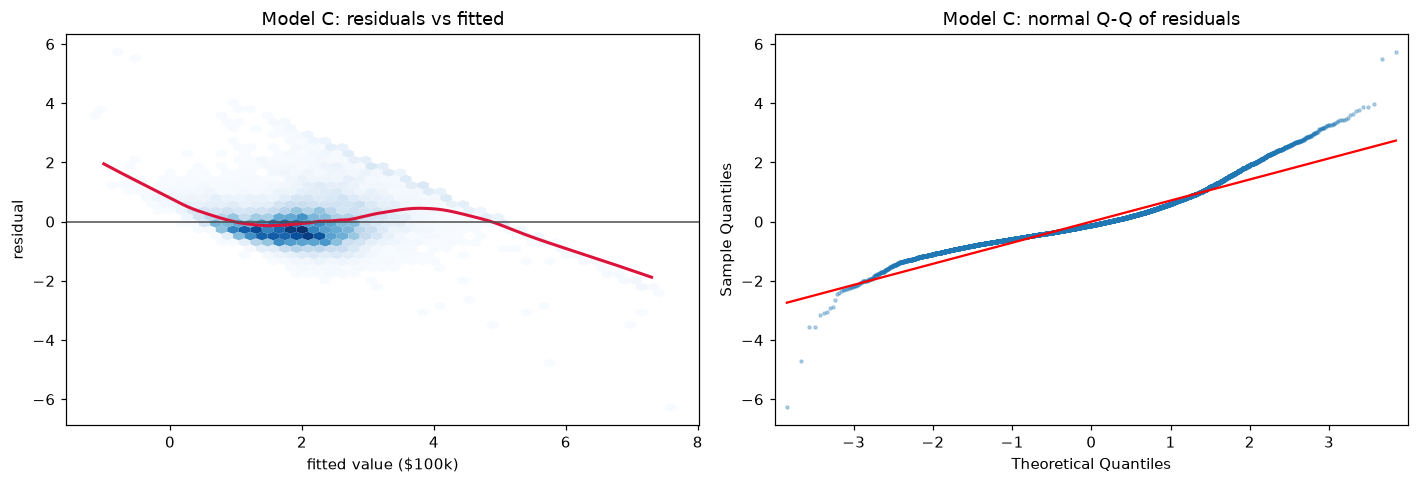

residual mean 0.0000 | sd 0.712 | skewness 1.08


In [18]:
res_C = resid_diagnostics(model_C, transform(train), ytr, "Model C")

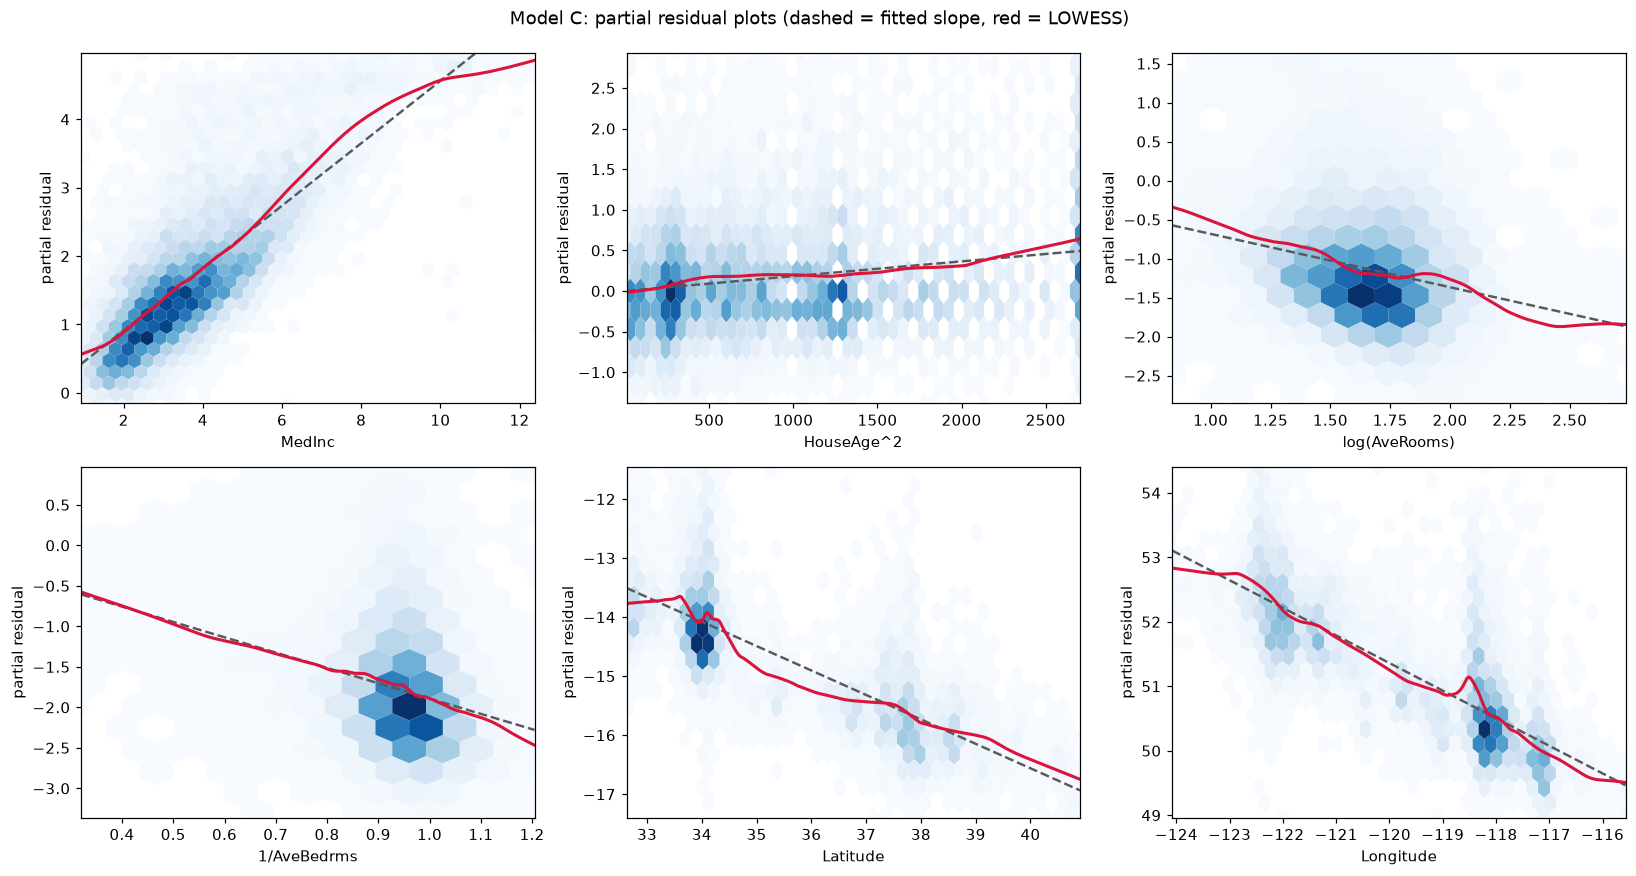

In [19]:
partial_residual_plots(model_C, transform(train), res_C, "Model C")

**What improved.** In the partial residual plots, $\log(\text{AveRooms})$ and $1/\text{AveBedrms}$ now
track the fitted slope closely through the dense region: those two features *are* approximately linear in
their transformed form, which is exactly what the transformation was for. $\text{HouseAge}^2$ is
straight except at the top, where the age variable is itself capped at 52 years. Accuracy improves
modestly and consistently.

**What did not improve.** Residuals vs fitted still curves and still fans out. Skewness is unchanged at
about 1.1. Predictions below zero persist. The latitude and longitude panels are untouched, as they must
be, since those features were not transformed.

spatial autocorrelation of residuals:  Model A 0.691   ->   Model C 0.675


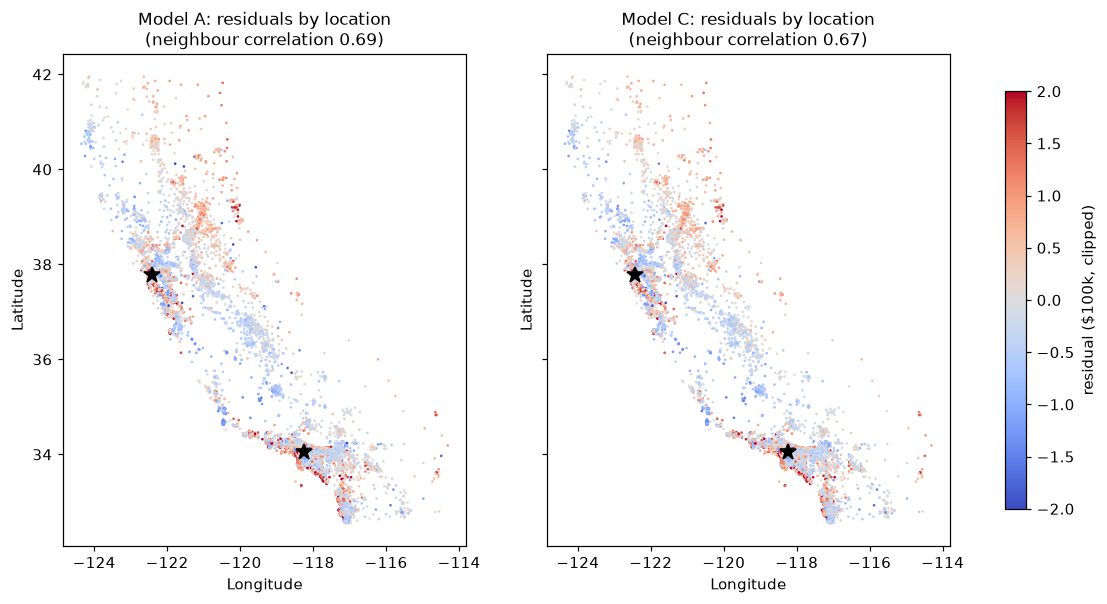

In [20]:
ac_C = spatial_autocorr(train, res_C)
print(f"spatial autocorrelation of residuals:  Model A {ac_A:.3f}   ->   Model C {ac_C:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.8), sharex=True, sharey=True)
for ax, res, name, ac in [(axes[0], res_A, "Model A", ac_A), (axes[1], res_C, "Model C", ac_C)]:
    sc = ax.scatter(train.Longitude, train.Latitude, c=np.clip(res, -2, 2), s=3,
                    cmap="coolwarm", vmin=-2, vmax=2, linewidths=0)
    ax.set(xlabel="Longitude", ylabel="Latitude")
    ax.set_title(f"{name}: residuals by location\n(neighbour correlation {ac:.2f})", fontsize=11)
    for label, (la, lo) in {"SF": (37.77, -122.42), "LA": (34.05, -118.24)}.items():
        ax.plot(lo, la, "k*", ms=11)
fig.colorbar(sc, ax=axes, label="residual ($100k, clipped)", shrink=0.85)
plt.show()

The residual map is barely changed. Transforming the dwelling-size features cannot fix an error structure
that is geographic.

### Demonstrating that geography is the binding constraint

If the diagnosis is right, then replacing the coordinates with a feature that encodes *distance to an
expensive city* should help more than the whole per-feature exercise did. Using
$\log(1 + d)$, where $d$ is the great-circle distance in km to the nearer of San Francisco and Los Angeles:

In [21]:
SF, LA = (37.7749, -122.4194), (34.0522, -118.2437)


def km_to(d, point):
    return np.hypot((d.Latitude - point[0]) * 111,
                    (d.Longitude - point[1]) * 111 * np.cos(np.radians(d.Latitude)))


def transform_plus(d):
    X = transform(d)
    X["log(dist to SF/LA)"] = np.log(np.minimum(km_to(d, SF), km_to(d, LA)) + 1)
    return X


model_D = fit_report(transform_plus(train), ytr, transform_plus(test), yte,
                     transform_plus(df), df[TARGET], "D: C + log distance to SF/LA",
                     show_table=False)

R2 train 0.6354 | R2 test 0.6142 | 5-fold CV R2 0.6308 (sd 0.0103)
RMSE test 0.7110  (= $71,101)  |  MAE test 0.5148
predictions below zero (impossible prices): 12 of 4128


One extra column buys more than every transformation combined, which confirms the diagnosis: the
dominant misspecification is spatial.

### How much of the remaining error is the censoring cap?

Refit on the uncensored rows only. If the cap were harmless, the score would be unchanged.

In [22]:
uncapped = df[df[TARGET] < 5.0]
for name, builder in [("A (raw)", lambda d: d[FEATURES_6]), ("C (transformed)", transform)]:
    full = cross_val_score(LinearRegression(), builder(df), df[TARGET], cv=CV, scoring="r2").mean()
    unc = cross_val_score(LinearRegression(), builder(uncapped), uncapped[TARGET], cv=CV, scoring="r2").mean()
    print(f"{name:16s} CV R2  all rows {full:.4f} | uncensored rows only {unc:.4f}")

A (raw)          CV R2  all rows 0.6028 | uncensored rows only 0.5703
C (transformed)  CV R2  all rows 0.6163 | uncensored rows only 0.5853


$R^2$ *falls* when the censored rows are removed. Those 5% of block groups, all sitting at exactly 5.0
with high incomes, are easy points that were inflating the apparent fit rather than being modelled well.

## 8. Summary of all models

In [23]:
summary = pd.DataFrame(RESULTS).set_index("model").round(4)
summary["RMSE_$"] = (summary.RMSE_test * 1e5).round(0)
summary

,k,R2_train,R2_test,CV_R2,CV_sd,RMSE_test,MAE_test,neg_preds,RMSE_$
model,,,,,,,,,
A: 6 selected features,6,0.6113,0.5750,0.6028,0.0082,0.7463,0.5340,15,74630.0
B: all 8 features,8,0.6126,0.5758,0.6037,0.0079,0.7456,0.5332,15,74560.0
C: 6 transformed features,6,0.6205,0.6016,0.6163,0.0112,0.7226,0.5226,12,72260.0
D: C + log distance to SF/LA,7,0.6354,0.6142,0.6308,0.0103,0.7110,0.5148,12,71100.0


## 9. Conclusions

**Feature selection.** Six features (`MedInc`, `HouseAge`, `AveRooms`, `AveBedrms`, `Latitude`,
`Longitude`) match the full eight-feature model to within 0.001 of test $R^2$. `Population` is
insignificant and `AveOccup` contributes a practically negligible coefficient, so the smaller model is
preferred on parsimony grounds.

**Linearity.** Mostly absent. Only `MedInc` is genuinely linear in the target across its range.
`HouseAge` is mildly convex, `AveRooms` and `AveBedrms` are nonlinear and collinear at $r = 0.85$, and
the coordinates are bimodal, so their fitted slopes are meaningless as descriptions of how location
prices housing. The residual diagnostics also reject constant variance and normality, and show a
neighbour correlation of about 0.70, meaning the errors are spatially structured.

**Transformation.** One simple function per feature ($\text{HouseAge}^2$, $\log \text{AveRooms}$,
$1/\text{AveBedrms}$, `MedInc` untouched) raises cross-validated $R^2$ from 0.603 to 0.616 and cuts test
RMSE by roughly \$1,200. The partial residual plots confirm the transformed features are much closer to
linear individually. The overall residual structure barely moves, because the remaining misspecification
is geographic rather than per-feature, which the distance experiment demonstrates directly.

**What a fuller treatment would need**, in rough order of expected payoff: spatial features or spatial
smoothing instead of raw coordinates; an interaction or spline basis rather than one monotone function
per feature; a tobit-style or censored-regression treatment of the \$500,001 ceiling; robust or
heteroscedasticity-consistent standard errors; and, if interpretation of the room variables matters,
replacing the collinear pair with bedroom share $\text{AveBedrms}/\text{AveRooms}$ and total rooms.

Use the wine recognition dataset available in scikit-learn ([https://scikit-learn.org/stable/datasets/toy_dataset.html#wine-recognition-dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#wine-recognition-dataset)) and perform the following:

- Load the dataset in Python or Jupyter.
- Choose four to eight features (up to you) that you think are best to predict wine type.
- Train a simple linear model (logistic regression) and elaborate, based on your results, whether the features you selected are linearly separable or not. Compare your results with training the same model on the full set of features.
- Try a single simple transformation (like different mathematical functions for each feature) of your selected features and evaluate if your new transformed features are linearly separable by plotting the residuals.

<class 'sklearn.utils._bunch.Bunch'>
(178, 13)
(178,)
<class 'pandas.DataFrame'>
          alcohol  malic_acid       ash  alcalinity_of_ash   magnesium  total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity       hue  od280/od315_of_diluted_wines  \
target                                                                                                                                                                                              
0       13.744746    2.010678  2.455593          17.037288  106.338983       2.840169    2.982373              0.290000         1.899322         5.528305  1.062034                      3.157797   
1       12.278732    1.932676  2.244789          20.238028   94.549296       2.258873    2.080845              0.363662         1.630282         3.086620  1.056282                      2.785352   
2       13.153750    3.333750  2.437083          21.416667   99.312500       1.678750    0.781458              0.447500         1.1

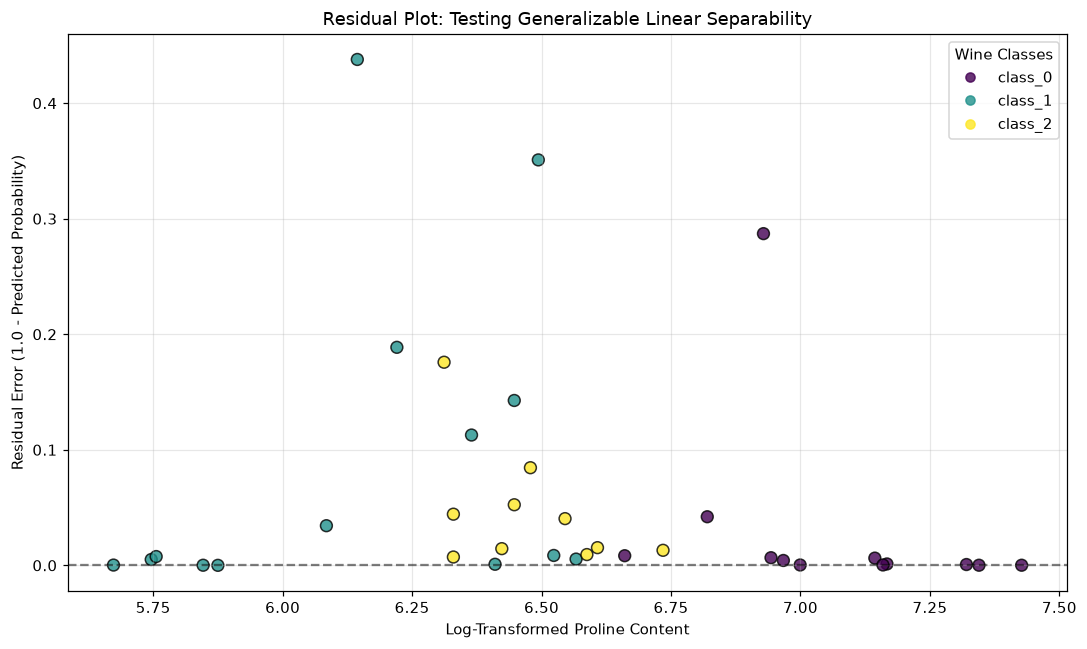

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


def main():
    """
    To ideally determine which features to use, we must group each of the columns
    and calculate their means and standard deviations.
    If the means of the groups are similar and the standard deviation is small then the groups barely overlap.
    """

    dataset = load_wine(
        as_frame=True
    )  # true changes the output from a numpy array to a pandas dataframe
    print(type(dataset))
    # print(dataset.keys())

    # pandas dataframe and feature names
    # print(dataset.feature_names)
    # print(dataset.target_names)
    # print(dataset.target)
    # print(dataset.frame)
    # print(dataset.data)
    # print(dataset.DESCR)

    # we put out the wine data in X and the targets in y
    X = dataset.data
    y = dataset.target
    print(X.shape)  # (instances, attributes)
    print(y.shape)

    print(type(dataset.frame))
    print(
        dataset.frame.groupby("target").mean()
    )  # compare the means of the groups to see if there is a signiicance
    print(
        dataset.frame.groupby("target").std()
    )  # using the mean leverage the stds to see if there is a signiicance between the groups
    means = dataset.frame.groupby("target").mean()
    stds = dataset.frame.groupby("target").std()

    mean_diff_classoneandtwo = (
        means.loc[1] - means.loc[2]
    )  # finding mean differences between classes 1 and 2 to test for significance
    avg_std_classoneandtwo = (
        (stds.loc[1] + stds.loc[2]) / 2
    )  # finding std avg between two classes (1 and 2) so it can be used to find the amount of deviations
    significant_feature_classoneandtwo = (
        mean_diff_classoneandtwo / avg_std_classoneandtwo
    )  # OD280 (2.87), color intensity (2.66), flavanoids (2.60) and hue (2.35) are most significant

    mean_diff_classzeroandtwo = (
        means.loc[0] - means.loc[2]
    )  # finding mean differences between classes 0 and 2 to test for significance
    avg_std_classzeroandtwo = (
        (stds.loc[0] + stds.loc[2]) / 2
    )  # finding std avg between two classes (0 and 2) so it can be used to find the amount of deviations
    significant_feature_classzeroandtwo = (
        mean_diff_classzeroandtwo / avg_std_classzeroandtwo
    )  # flavanoids (6.37), OD280 (4.69) and hue (3.29)

    mean_diff_classzeroandone = (
        means.loc[0] - means.loc[1]
    )  # finding mean differences between classes 0 and 1 to test for significance
    avg_std_classzeroandone = (
        (stds.loc[0] + stds.loc[1]) / 2
    )  # finding std avg between two classes (0 and 1) so it can be used to find the amount of deviations
    significant_feature_classzeroandone = (
        mean_diff_classzeroandone / avg_std_classzeroandone
    )  # proline (3.15), alcohol (2.93), and (2.26)

    print(significant_feature_classoneandtwo)
    print(significant_feature_classzeroandtwo)
    print(significant_feature_classzeroandone)

    # ideal feature picks: flavanoids, proline, hue, OD280 and alcohol
    feature_picks = [
        "flavanoids",
        "proline",
        "hue",
        "od280/od315_of_diluted_wines",
        "alcohol",
    ]
    feature_table = dataset.frame[feature_picks]
    print(feature_table)

    # log reg model with the selected features
    # we split the data into training and testing sets in a shuffle and then stratisfied format.
    X_train, X_test, y_train, y_test = train_test_split(
        feature_table, y, test_size=0.2, random_state=42, stratify=y
    )
    # realized that the features dont converge even at max iterations, so using stadardization will solve this.
    wine_scaler = StandardScaler()
    X_train = wine_scaler.fit_transform(X_train)
    X_test = wine_scaler.transform(X_test)
    print(X_train.shape, X_test.shape)  # to verify the shapes

    # log reg model
    model = LogisticRegression()
    model.fit(X_train, y_train)
    print(model.score(X_test, y_test))
    # the feautures are linearly separable because the wine groups are so distinct that they sit in separae piles meaning logistic regression can easily grpah through these points.

    # The assignment now asks to compare your results with training the same model on the full set of features.

    #TO DO SO:
    #create a second split with 13 features instead of 5
    #then split the training set and test set
    #then train and test the model

    X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
        dataset.data, y, test_size=0.2, random_state=42, stratify=y
    )
   
    wine_scaler = StandardScaler()
    X_train_full = wine_scaler.fit_transform(X_train_full)
    X_test_full = wine_scaler.transform(X_test_full)
    print(X_train_full.shape, X_test_full.shape)  # to verify the shapes

    model_full = LogisticRegression()
    model_full.fit(X_train_full, y_train_full)
    print(model_full.score(X_test_full, y_test_full)) 
    #score of 0.977 which is barely any different from the 5 feature model

    
    #The honest conclusion is that both models perform about equally well, around 97 to 100%, 
    #and that a single split can't distinguish them. 
    #It's also a more interesting result than it first looks as five features do as well as all 13. 
    #That's important, since it means the eight features dropped didn't improve the predictions once these five were in.
    
#feature tranformation and residual
    #feature transformation using log, square, root and exponential

    
    X_transformed = pd.DataFrame()
    X_transformed["flavanoids_sq"] = feature_table["flavanoids"] ** 2
    X_transformed["proline_log"] = np.log1p(feature_table["proline"]) #using log1p to avoid working with zeros and negative values
    X_transformed["hue_cube"] = feature_table["hue"] ** 3
    X_transformed["od280_sqrt"] = np.sqrt(feature_table["od280/od315_of_diluted_wines"])
    X_transformed["alcohol_exp"] = np.exp(feature_table["alcohol"] / 10)

    X_train_transformed, X_test_transformed, y_train_transformed, y_test_transformed = train_test_split(
            X_transformed, y, test_size=0.2, random_state=42, stratify=y)

    transformed_scaler = StandardScaler()
    X_train_transformed_scaled = transformed_scaler.fit_transform(X_train_transformed)
    X_test_transformed_scaled = transformed_scaler.transform(X_test_transformed)

    #fitting the new model with the transformed features
    model_transformed = LogisticRegression(random_state=42)
    model_transformed.fit(X_train_transformed_scaled, y_train_transformed)

    #testing the model
    test_score = model_transformed.score(X_test_transformed_scaled, y_test_transformed)
    print(test_score)

    #residuals (difference between actual and prediction)
    test_probabilities = model_transformed.predict_proba(X_test_transformed_scaled)
    actual_class_test_proba = test_probabilities[
        np.arange(len(y_test_transformed)), y_test_transformed
    ]
    test_residuals = 1.0 - actual_class_test_proba
    print(test_residuals)

    #plotting the residuals

    plt.figure(figsize=(10, 6))
    plt.axhline(
        y=0, color="black", linestyle="--", alpha=0.5, label="Perfect Confidence Floor"
    )

    scatter = plt.scatter(
        X_test_transformed["proline_log"],
        test_residuals,
        c=y_test_transformed,
        cmap="viridis",
        edgecolors="k",
        alpha=0.8,
        s=60,
    )

    plt.xlabel("Log-Transformed Proline Content")
    plt.ylabel("Residual Error (1.0 - Predicted Probability)")
    plt.title("Residual Plot: Testing Generalizable Linear Separability")

    handles, _ = scatter.legend_elements()
    plt.legend(handles, dataset.target_names, title="Wine Classes")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("residual_plot.png")
"""
The model is very confident at the extremes but less certain in the middle 
because the various proline values isolate distinct classes at far ends, 
but then overlap significantly in the center.
"""

if __name__ == "__main__":
    main()


For the feature selection we decided to compare the mean of each feature per class, then divided the difference between two classes by their average standard deviation, to get how many deviations apart each pair sits. Results:

| pair | strongest features |
|---|---|
| 0 vs 1 | proline 3.15, alcohol 2.93, colour intensity 2.26 |
| 1 vs 2 | OD280 2.87, colour intensity 2.66, flavanoids 2.60, hue 2.35 |
| 0 vs 2 | flavanoids 6.37, OD280 4.69, total phenols 3.34, hue 3.29 |

Based on the results, we looked at how closely the means were related and by how many deviations it was different by. As a result, we picked flavanoids, proline, hue, OD280, alcohol. This is so that every pair has at least two strong features. What could be see was that Ash was the counter-example based on the aforementioned; wherein, the means 2.46/2.24/2.44, were all under one standard deviation apart, so it carried nothing. As far as the standardization is concerned, they start leading to bad step sizes and then also start to distort the gradients. Let's look at Proline as an example, it is in the hundreds/thousands whilst hue is around 1. However, the solver uses one step size for all features; as a result, it hit the 100-iteration limit due to not converging properly. In order to fix this, we used scaling causing the convergence warning to disappear and the accuracy increased from 0.889 to 1.00.

Now looking at the split, it'd be biased since it is divided by class; whereby, the y is sorted 0s, then 1s, then 2s, so an in-order split would put only class 2 in the test set. To fix that, we realized that the data needed to be shuffled and put in a random order using the random_state function as well as needed to be stratified by setting stratisy = y. Additionally, leakage was also quite a concern since we already split the data to our test set and so introducing that in the training process may lead to exceptional accuracy. To adjust that, we used a fit_transform on the training set and the transform on the test set, both hidden from each other.

The assignment asked to compare the five specialized features model to one that uses 1.00 vs 0.972, one wine out of 36. Here, we see the five feature models perform just as good as the model using all features. Out of curiosity, I decided to change the random_state from 42 to 56, where the five feature output score fell to 0.972. So we can say, the difference sits inside the variation from the split itself, and one split can't separate the two models. To solve this issue we should use cross validation.

Applying mathematical transformations was also done to compare two of the same five feature models. Here, we set flavanoids², log1p(proline), hue³, √OD280, exp(alcohol/10). In the output, the score stayed as 1.00. The reason for this is because the functions are monotonic, so ordering is preserved and a straight boundary still separates the classes. We also decided to find the residual plot where the residual is 1 - probability the model gave the wine's true class. However, mostly all were near zero, the largest was 0.438, and three of them above 0.25. It is worth mentioning that even the worst was still classified correctly, so nothing here argues against linear separability. We can conclude that the model is highly confident at the extremes but less certain in the middle because proline values isolate distinct classes at far ends, but overlap significantly in the center. We see it matches the numbers, where proline separates 0 from 1 well (3.15) but 1 from 2 poorly (0.81), and the middle is where classes 1 and 2 sit on top of each other. Those wines are still classified right, which means the other four features are accurate.